# ***Ingeniería de características***

**Proyecto:** Detección, clasificación y medición de barras/anillos en galaxias  
**Equipo:** 39

## Propósito

Este notebook crea la sección de **ingeniería de características** a partir de imágenes astronómicas en bandas **g, r, z**. La idea es preparar un dataset "final" que represente mejor la estructura visual de cada galaxia para después poder construir un modelo.

# Objetivos
- **2.3** Construir variables nuevas que le den más contexto a los modelos.
- **2.4** Bajar el peso de variables sesgadas y hacer que el entrenamiento sea menos inestable mediante transformación, discretización, codificación, escalamiento, selección y extracción de características.

## ¿Por qué transformamos con Lupton?

Las imágenes astronómicas suelen tener rangos de intensidad muy amplios: el centro de una galaxia puede ser muy brillante, mientras que brazos, barras o anillos pueden ser mucho más tenues. Una normalización lineal simple puede saturar el centro y ocultar estructuras débiles. La composición propuesta por **Lupton et al. (2004)** usa una transformación tipo *asinh* para comprimir intensidades altas y conservar información en regiones de bajo brillo.

En este notebook usamos Lupton con distintos parámetros `Q`, `stretch` y pesos por banda; lo cual nos permite aproximar dos objetivos:

- una imagen que sea más interpretable visualmente para revisión humana
- una representación que conserve patrones útiles para modelos de clasificación posteriores.

## Ingeniería de características

El notebook genera distintas variables, agrupadas en:

- **estadísticos por banda:** media, desviación estándar, percentiles, IQR, rango robusto;
- **estructura radial:** intensidad central, zona interna, zona media, zona externa, contraste interno/externo y posible pico radial compatible con anillos;
- **textura y bordes:** entropía y respuesta promedio de bordes con Sobel;
- **asimetría:** comparación contra flips y rotación de 180°;
- **forma global:** centroide, momentos, elongación y elipticidad;
- **color relativo:** diferencias y razones entre bandas `z`, `r`, `g`;
- **features de la mejor imagen Lupton/RGB:** variables calculadas sobre la imagen visual final seleccionada.

Estas variables son interpretables y sirven como puente entre la imagen astronómica cruda, con el modelo posterior.

In [32]:
from pathlib import Path
import json
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.visualization import make_lupton_rgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.feature_selection import VarianceThreshold, f_classif, chi2
from sklearn.decomposition import PCA, FactorAnalysis

try:
    from factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
    FACTOR_ANALYZER_AVAILABLE = True
except Exception:
    FACTOR_ANALYZER_AVAILABLE = False

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        expected = candidate / "data_download" / "catalogs" / "clasification" / "classification_dataset.csv"
        if expected.exists():
            return candidate
    raise FileNotFoundError("No se encontró classification_dataset.csv desde la ruta actual")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data_download" / "catalogs" / "clasification" / "classification_dataset.csv"
IMAGE_DIR = PROJECT_ROOT / "data_download" / "data"
OUTPUT_DIR = PROJECT_ROOT / "feature_engineering" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", "{:.6f}".format)


## Verificación de datos

Primero cargamos el catálogo, se buscan las imágenes FITS locales y se conectan con cada fila cuando existe coincidencia. Con eso queda separada la información física de columnas más administrativas, como `has_fits`, que sirven para controlar el flujo pero no deberían confundirse con una señal astronómica.



In [20]:
df = pd.read_csv(DATA_PATH)
fits_files = sorted(IMAGE_DIR.glob("*.fits"))

FITS_PATTERN = re.compile(
    r"^\d+_(?:sin_anillo|anillo_interno)_(?P<name>.+)_ra[-+0-9.]+_dec[-+0-9.]+\.fits$"
)

fits_map = {}
unparsed_files = []
for path in fits_files:
    match = FITS_PATTERN.match(path.name)
    if match:
        fits_map[match.group("name")] = path
    else:
        unparsed_files.append(path.name)

df["fits_path"] = df["name"].astype(str).map(fits_map)
df["has_fits"] = df["fits_path"].notna().astype(int)

status = {
    "catalog_rows": int(len(df)),
    "catalog_columns": int(df.shape[1]),
    "missing_values_total": int(df.isna().drop(columns=["fits_path"]).sum().sum()),
    "unique_names": int(df["name"].nunique()),
    "fits_files_found": len(fits_files),
    "fits_files_matched_to_catalog": int(df["has_fits"].sum()),
    "catalog_rows_without_fits": int((df["has_fits"] == 0).sum()),
    "unparsed_fits_filenames": len(unparsed_files),
}

print(json.dumps(status, indent=2, ensure_ascii=False))
display(df.head())


{
  "catalog_rows": 8408,
  "catalog_columns": 9,
  "missing_values_total": 0,
  "unique_names": 8407,
  "fits_files_found": 8110,
  "fits_files_matched_to_catalog": 8110,
  "catalog_rows_without_fits": 298,
  "unparsed_fits_filenames": 0
}


,name,objra,objdec,nsa_z,anillos,source,label,fits_path,has_fits
0,1237648721210769659,134.447170,-0.199973,0.028206,0,sdss,0,/home/camilo/Documents/school/proyecto-integra...,1
1,1237648705657307354,198.233560,0.941188,0.048037,0,sdss,0,/home/camilo/Documents/school/proyecto-integra...,1
2,1237648705120895059,199.294920,0.527571,0.024114,0,sdss,0,/home/camilo/Documents/school/proyecto-integra...,1
3,1237648720150724863,165.740610,-0.962095,0.033483,0,sdss,0,/home/camilo/Documents/school/proyecto-integra...,1
4,1237649919509594232,31.372020,13.251016,0.024694,0,sdss,0,/home/camilo/Documents/school/proyecto-integra...,1


In [21]:
print("Distribución label:")
display(df["label"].value_counts().sort_index().rename(index={0: "sin_anillo", 1: "anillo_interno"}).to_frame("n"))

print("Cruce source x label:")
display(pd.crosstab(df["source"], df["label"], margins=True))

print("Cobertura FITS por clase:")
display(pd.crosstab(df["label"], df["has_fits"], margins=True))

print("Resumen numérico base:")
display(df[["objra", "objdec", "nsa_z"]].describe().T)


Distribución label:


,n
label,
sin_anillo,6660
anillo_interno,1748


Cruce source x label:


label,0,1,All
source,,,
manga,0,519,519
sdss,6660,1229,7889
All,6660,1748,8408


Cobertura FITS por clase:


has_fits,0,1,All
label,,,
0,244,6416,6660
1,54,1694,1748
All,298,8110,8408


Resumen numérico base:


,count,mean,std,min,25%,50%,75%,max
objra,8408.000000,184.446684,60.416394,0.008759,153.919755,187.315235,221.198660,359.276680
objdec,8408.000000,25.326774,18.348607,-11.015802,10.620792,24.390116,39.501162,70.133229
nsa_z,8408.000000,0.036265,0.015922,0.007122,0.024736,0.032989,0.045070,0.147977


**Notas:**

- El catálogo trae 8408 galaxias y, al menos en las columnas base, no pide imputación.
- Tenemos descargadas las imágenes FITS que sí se pueden enlazar con el catálogo. Las filas sin FITS siguen siendo útiles para análisis tabular, pero cualquier modelo que use imágenes tendrá que filtrar `has_image_features=1`.


In [34]:
def add_tabular_features(input_df: pd.DataFrame) -> pd.DataFrame:
    out = input_df.copy()
    out["ra_rad"] = np.deg2rad(out["objra"])
    out["dec_rad"] = np.deg2rad(out["objdec"])
    out["ra_sin"] = np.sin(out["ra_rad"])
    out["ra_cos"] = np.cos(out["ra_rad"])
    out["dec_sin"] = np.sin(out["dec_rad"])
    out["dec_cos"] = np.cos(out["dec_rad"])

    coords = SkyCoord(
        ra=out["objra"].to_numpy() * u.degree,
        dec=out["objdec"].to_numpy() * u.degree,
        frame="icrs",
    )
    out["gal_l"] = coords.galactic.l.degree
    out["gal_b"] = coords.galactic.b.degree
    out["gal_l_sin"] = np.sin(np.deg2rad(out["gal_l"]))
    out["gal_l_cos"] = np.cos(np.deg2rad(out["gal_l"]))
    out["gal_b_sin"] = np.sin(np.deg2rad(out["gal_b"]))
    out["gal_b_abs"] = np.abs(out["gal_b"])

    out["z_log1p"] = np.log1p(out["nsa_z"])
    out["z_sqrt"] = np.sqrt(out["nsa_z"].clip(lower=0))
    return out

fe = add_tabular_features(df)

z_skew = pd.Series(
    {
        "nsa_z_raw": skew(fe["nsa_z"]),
        "z_log1p": skew(fe["z_log1p"]),
        "z_sqrt": skew(fe["z_sqrt"]),
    },
    name="skewness",
).to_frame()
display(z_skew)


,skewness
nsa_z_raw,1.188716
z_log1p,1.116261
z_sqrt,0.499480


**Decisión:** me quedo con `sqrt(z)` como versión principal del redshift. En este rango bajo reduce mejor la asimetría que `log1p(z)` y, además, no rompe el orden físico aproximado de distancia. Pequeño detalle, pero ayuda.


## Características de imagen

Cada archivo FITS viene como un cubo `(3, 800, 800)` con bandas `g`, `r`, `z`. Meter todo eso directo al dataset sería pesado y poco práctico, así que se resume cada imagen con variables pequeñas pero informativas:

- brillo robusto por banda: percentil 99 y flujo positivo en escala logarítmica;
- color aproximado: diferencias de log-flujo entre `g-r` y `r-z`;
- morfología en banda `r`: concentración central, razón flujo externo/interno, radio del pico radial, contraste anular y asimetría a 180 grados;
- composición **Lupton RGB** (`z -> R`, `r -> G`, `g -> B`) con stretch asinh para medir luminancia, saturación/color y morfología sobre una imagen compuesta. Para que el cálculo no se vuelva eterno con más de 8 mil FITS, Lupton se calcula sobre una grilla submuestreada; las features por banda sí se toman del FITS original.

Si hay un anillo interno, debería dejar alguna pista alrededor del centro de la galaxia. No basta con que cambien las coordenadas o el redshift. ¿Se puede capturar perfecto con estos descriptores? Probablemente no, pero sí dan una señal visual más cercana al fenómeno que se quiere detectar.


In [5]:
GEOMETRY_CACHE = {}


def geometry_for_shape(height: int, width: int) -> dict:
    key = (height, width)
    if key in GEOMETRY_CACHE:
        return GEOMETRY_CACHE[key]

    y, x = np.indices((height, width))
    cy = (height - 1) / 2
    cx = (width - 1) / 2
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    rnorm = r / r.max()

    bins = np.linspace(0, 0.65, 33)
    bin_idx = np.digitize(rnorm.ravel(), bins) - 1
    valid = (bin_idx >= 0) & (bin_idx < len(bins) - 1)
    bin_idx_valid = bin_idx[valid]
    bin_counts = np.bincount(bin_idx_valid, minlength=len(bins) - 1)

    geom = {
        "rnorm": rnorm,
        "center_mask": rnorm <= 0.10,
        "inner_mask": rnorm <= 0.20,
        "outer_mask": (rnorm > 0.20) & (rnorm <= 0.60),
        "bins": bins,
        "valid_flat": valid,
        "bin_idx_valid": bin_idx_valid,
        "bin_counts": bin_counts,
    }
    GEOMETRY_CACHE[key] = geom
    return geom


def robust_asinh_stretch(band: np.ndarray) -> np.ndarray:
    lo, hi = np.nanpercentile(band, [0.5, 99.5])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(band, dtype="float32")
    scaled = np.clip(band, lo, hi)
    scaled = (scaled - lo) / (hi - lo + 1e-8)
    return (np.arcsinh(10 * scaled) / np.arcsinh(10)).astype("float32")


def radial_morphology_features(image: np.ndarray, prefix: str) -> dict:
    geom = geometry_for_shape(*image.shape)
    total_flux = float(image.sum() + 1e-8)
    inner_flux = float(image[geom["inner_mask"]].sum())
    outer_flux = float(image[geom["outer_mask"]].sum())

    radial_values = image.ravel()[geom["valid_flat"]]
    radial_sums = np.bincount(
        geom["bin_idx_valid"],
        weights=radial_values,
        minlength=len(geom["bins"]) - 1,
    )
    radial_profile = radial_sums / (geom["bin_counts"] + 1e-8)
    search_profile = radial_profile[6:]
    peak_idx = int(np.nanargmax(search_profile)) + 6
    profile_baseline = float(np.nanmedian(radial_profile[6:]))
    profile_peak = float(radial_profile[peak_idx])

    return {
        f"{prefix}_center_mean": float(image[geom["center_mask"]].mean()),
        f"{prefix}_concentration_20": inner_flux / total_flux,
        f"{prefix}_outer_to_inner_flux": outer_flux / (inner_flux + 1e-8),
        f"{prefix}_peak_radius_norm": float((geom["bins"][peak_idx] + geom["bins"][peak_idx + 1]) / 2),
        f"{prefix}_ring_contrast": (profile_peak - profile_baseline) / (profile_baseline + 1e-8),
        f"{prefix}_asymmetry_180": float(np.abs(image - np.rot90(image, 2)).sum() / total_flux),
    }


LUPTON_DOWNSAMPLE = 4


def compute_lupton_features(cube: np.ndarray) -> dict:
    # Lupton RGB: longitudes de onda largas en rojo, intermedias en verde y cortas en azul.
    cube_lupton = cube[:, ::LUPTON_DOWNSAMPLE, ::LUPTON_DOWNSAMPLE]
    rgb = make_lupton_rgb(cube_lupton[2], cube_lupton[1], cube_lupton[0], Q=8, stretch=5, output_dtype=float)
    rgb = np.nan_to_num(rgb, nan=0.0, posinf=0.0, neginf=0.0)
    rgb = np.clip(rgb, 0.0, 1.0)

    luminance = (0.2126 * rgb[:, :, 0] + 0.7152 * rgb[:, :, 1] + 0.0722 * rgb[:, :, 2]).astype("float32")
    rgb_max = rgb.max(axis=2)
    rgb_min = rgb.min(axis=2)
    saturation = ((rgb_max - rgb_min) / (rgb_max + 1e-8)).astype("float32")

    row = {
        "lupton_lum_mean": float(luminance.mean()),
        "lupton_lum_p99": float(np.nanpercentile(luminance, 99)),
        "lupton_lum_std": float(luminance.std()),
        "lupton_saturation_mean": float(saturation.mean()),
        "lupton_saturation_p95": float(np.nanpercentile(saturation, 95)),
        "lupton_red_dominance": float((rgb[:, :, 0] - rgb[:, :, 2]).mean()),
        "lupton_green_dominance": float((rgb[:, :, 1] - 0.5 * (rgb[:, :, 0] + rgb[:, :, 2])).mean()),
    }
    row.update(radial_morphology_features(luminance, "lupton_lum"))
    return row


def compute_fits_features(path: Path) -> dict:
    match = FITS_PATTERN.match(path.name)
    name = match.group("name") if match else path.stem

    with fits.open(path, memmap=True) as hdul:
        cube = hdul[0].data.astype("float32", copy=False)

    if cube.ndim != 3 or cube.shape[0] != 3:
        raise ValueError(f"Se esperaba FITS (3, H, W), recibido {cube.shape} en {path.name}")

    cube = np.nan_to_num(cube, nan=0.0, posinf=0.0, neginf=0.0)
    row = {"name": name}

    for band_idx, band_name in enumerate(["g", "r", "z"]):
        band = cube[band_idx]
        p99 = float(np.nanpercentile(band, 99))
        positive_flux = float(np.clip(band, 0, None).sum())
        row[f"img_{band_name}_log_p99_pos"] = float(np.log1p(max(p99, 0.0)))
        row[f"img_{band_name}_log_flux_pos"] = float(np.log1p(max(positive_flux, 0.0)))

    row["img_gr_log_flux_ratio"] = row["img_g_log_flux_pos"] - row["img_r_log_flux_pos"]
    row["img_rz_log_flux_ratio"] = row["img_r_log_flux_pos"] - row["img_z_log_flux_pos"]

    r_img = robust_asinh_stretch(cube[1])
    row.update(radial_morphology_features(r_img, "img_r"))
    row.update(compute_lupton_features(cube))

    return row


image_rows = []
failed_fits = []
matched_fits = [path for path in fits_files if FITS_PATTERN.match(path.name)]
print(f"Extrayendo características de {len(matched_fits)} imágenes FITS...")
for i, path in enumerate(matched_fits, start=1):
    try:
        image_rows.append(compute_fits_features(path))
    except Exception as exc:
        failed_fits.append({"file": path.name, "error": repr(exc)})
    if i % 1000 == 0 or i == len(matched_fits):
        print(f"  revisadas {i}/{len(matched_fits)} | exitosas {len(image_rows)} | fallidas {len(failed_fits)}")

image_features = pd.DataFrame(image_rows).drop_duplicates(subset="name", keep="first")
failed_fits = pd.DataFrame(failed_fits)
print("Dimensión de features de imagen:", image_features.shape)
print("FITS fallidos:", len(failed_fits))
display(image_features.head())
if len(failed_fits):
    display(failed_fits.head())


Extrayendo características de 8110 imágenes FITS...


/home/camilo/Documents/school/proyecto-integrador/RingGalaxiesAnalysis/venv/lib64/python3.14/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


  revisadas 1000/8110 | exitosas 1000 | fallidas 0


  revisadas 2000/8110 | exitosas 1998 | fallidas 2


  revisadas 3000/8110 | exitosas 2996 | fallidas 4


...

  revisadas 7000/8110 | exitosas 6993 | fallidas 7


  revisadas 8000/8110 | exitosas 7991 | fallidas 9


  revisadas 8110/8110 | exitosas 8101 | fallidas 9
Dimensión de features de imagen: (8100, 28)
FITS fallidos: 9


,name,img_g_log_p99_pos,img_g_log_flux_pos,img_r_log_p99_pos,img_r_log_flux_pos,img_z_log_p99_pos,img_z_log_flux_pos,img_gr_log_flux_ratio,img_rz_log_flux_ratio,img_r_center_mean,img_r_concentration_20,img_r_outer_to_inner_flux,img_r_peak_radius_norm,img_r_ring_contrast,img_r_asymmetry_180,lupton_lum_mean,lupton_lum_p99,lupton_lum_std,lupton_saturation_mean,lupton_saturation_p95,lupton_red_dominance,lupton_green_dominance,lupton_lum_center_mean,lupton_lum_concentration_20,lupton_lum_outer_to_inner_flux,lupton_lum_peak_radius_norm,lupton_lum_ring_contrast,lupton_lum_asymmetry_180
0,1237648721210769659,0.049235,8.297906,0.080056,8.731903,0.121030,9.221268,-0.433998,-0.489364,0.668376,0.164011,2.793059,0.375781,0.350620,0.488570,0.001342,0.020004,0.012882,0.531700,0.999997,0.001616,-0.000382,0.036196,0.441507,0.669817,0.375781,9.087729,1.071033
1,1237648705657307354,0.024986,7.533967,0.048408,8.061481,0.078898,8.817357,-0.527514,-0.755876,0.676120,0.082462,5.903942,0.436719,0.056391,0.358426,0.001032,0.011755,0.007088,0.500377,0.999998,0.001600,-0.000456,0.018506,0.302306,1.082666,0.599219,2.685408,1.180100
2,1237648705120895059,0.050461,8.197688,0.077588,8.666701,0.110183,9.122824,-0.469013,-0.456124,0.795744,0.107156,4.521581,0.132031,0.440253,0.377638,0.001371,0.019006,0.012965,0.508755,0.999997,0.001477,-0.000229,0.021048,0.291232,1.667826,0.274219,17.356050,1.327530
3,1237648720150724863,0.037335,7.548153,0.063991,8.109601,0.095000,8.692877,-0.561449,-0.583275,0.826466,0.088394,5.552271,0.132031,0.174447,0.334371,0.001057,0.015479,0.006310,0.516540,0.999997,0.001344,-0.000265,0.018895,0.336638,1.008926,0.132031,1.661365,1.148545
4,1237649919509594232,0.100694,8.429951,0.220712,9.299493,0.399126,10.045821,-0.869542,-0.746328,0.714856,0.241111,2.037736,0.132031,2.979716,0.529448,0.003883,0.061226,0.015377,0.683994,0.999997,0.005531,-0.000884,0.074567,0.582114,0.559758,0.132031,11.840139,1.164445


,file,error
0,001718_sin_anillo_1237657879150920168_ra118.42...,TypeError('buffer is too small for requested a...
1,001924_sin_anillo_1237658312943599812_ra196.55...,TypeError('buffer is too small for requested a...
2,002653_sin_anillo_1237661386534879289_ra225.41...,TypeError('buffer is too small for requested a...
3,002694_sin_anillo_1237661850928676917_ra172.53...,TypeError('buffer is too small for requested a...
4,003235_sin_anillo_1237662195065880632_ra192.63...,TypeError('buffer is too small for requested a...


In [35]:
fe = fe.merge(image_features, on="name", how="left")
image_feature_cols = [col for col in image_features.columns if col != "name"]
fe["has_image_features"] = fe[image_feature_cols].notna().all(axis=1).astype(int)

print("Cobertura de features de imagen después del merge:")
display(fe["has_image_features"].value_counts().sort_index().rename(index={0: "sin_features_imagen", 1: "con_features_imagen"}).to_frame("n"))


Cobertura de features de imagen después del merge:


,n
has_image_features,
sin_features_imagen,307
con_features_imagen,8101


### Panel visual

Las columnas de las imagenes:

| Vista | Qué muestra | Para qué sirve |
|---|---|---|
| `GRZ base` | Composición directa con bandas `z`, `r`, `g` normalizadas por percentiles | Dar una mirada amplia a brazos, núcleo y objetos vecinos. |
| `Lupton z/r/g` | Composición Lupton RGB con stretch asinh (`z -> R`, `r -> G`, `g -> B`) | Comprimir el rango dinámico sin borrar tanta estructura tenue. |
| `Máscara compacta` | Detección simple de fuentes compactas brillantes | Ubicar estrellas o artefactos que podrían contaminar las features. |
| `Fondo reducido` | Imagen Lupton con fondo suavizado atenuado | Ver mejor lo que pasa alrededor del centro. |
| `Realce anillos` | Diferencia de Gaussianas sobre luminancia | Hacer más visibles estructuras intermedias, parecidas a anillos o brazos. |


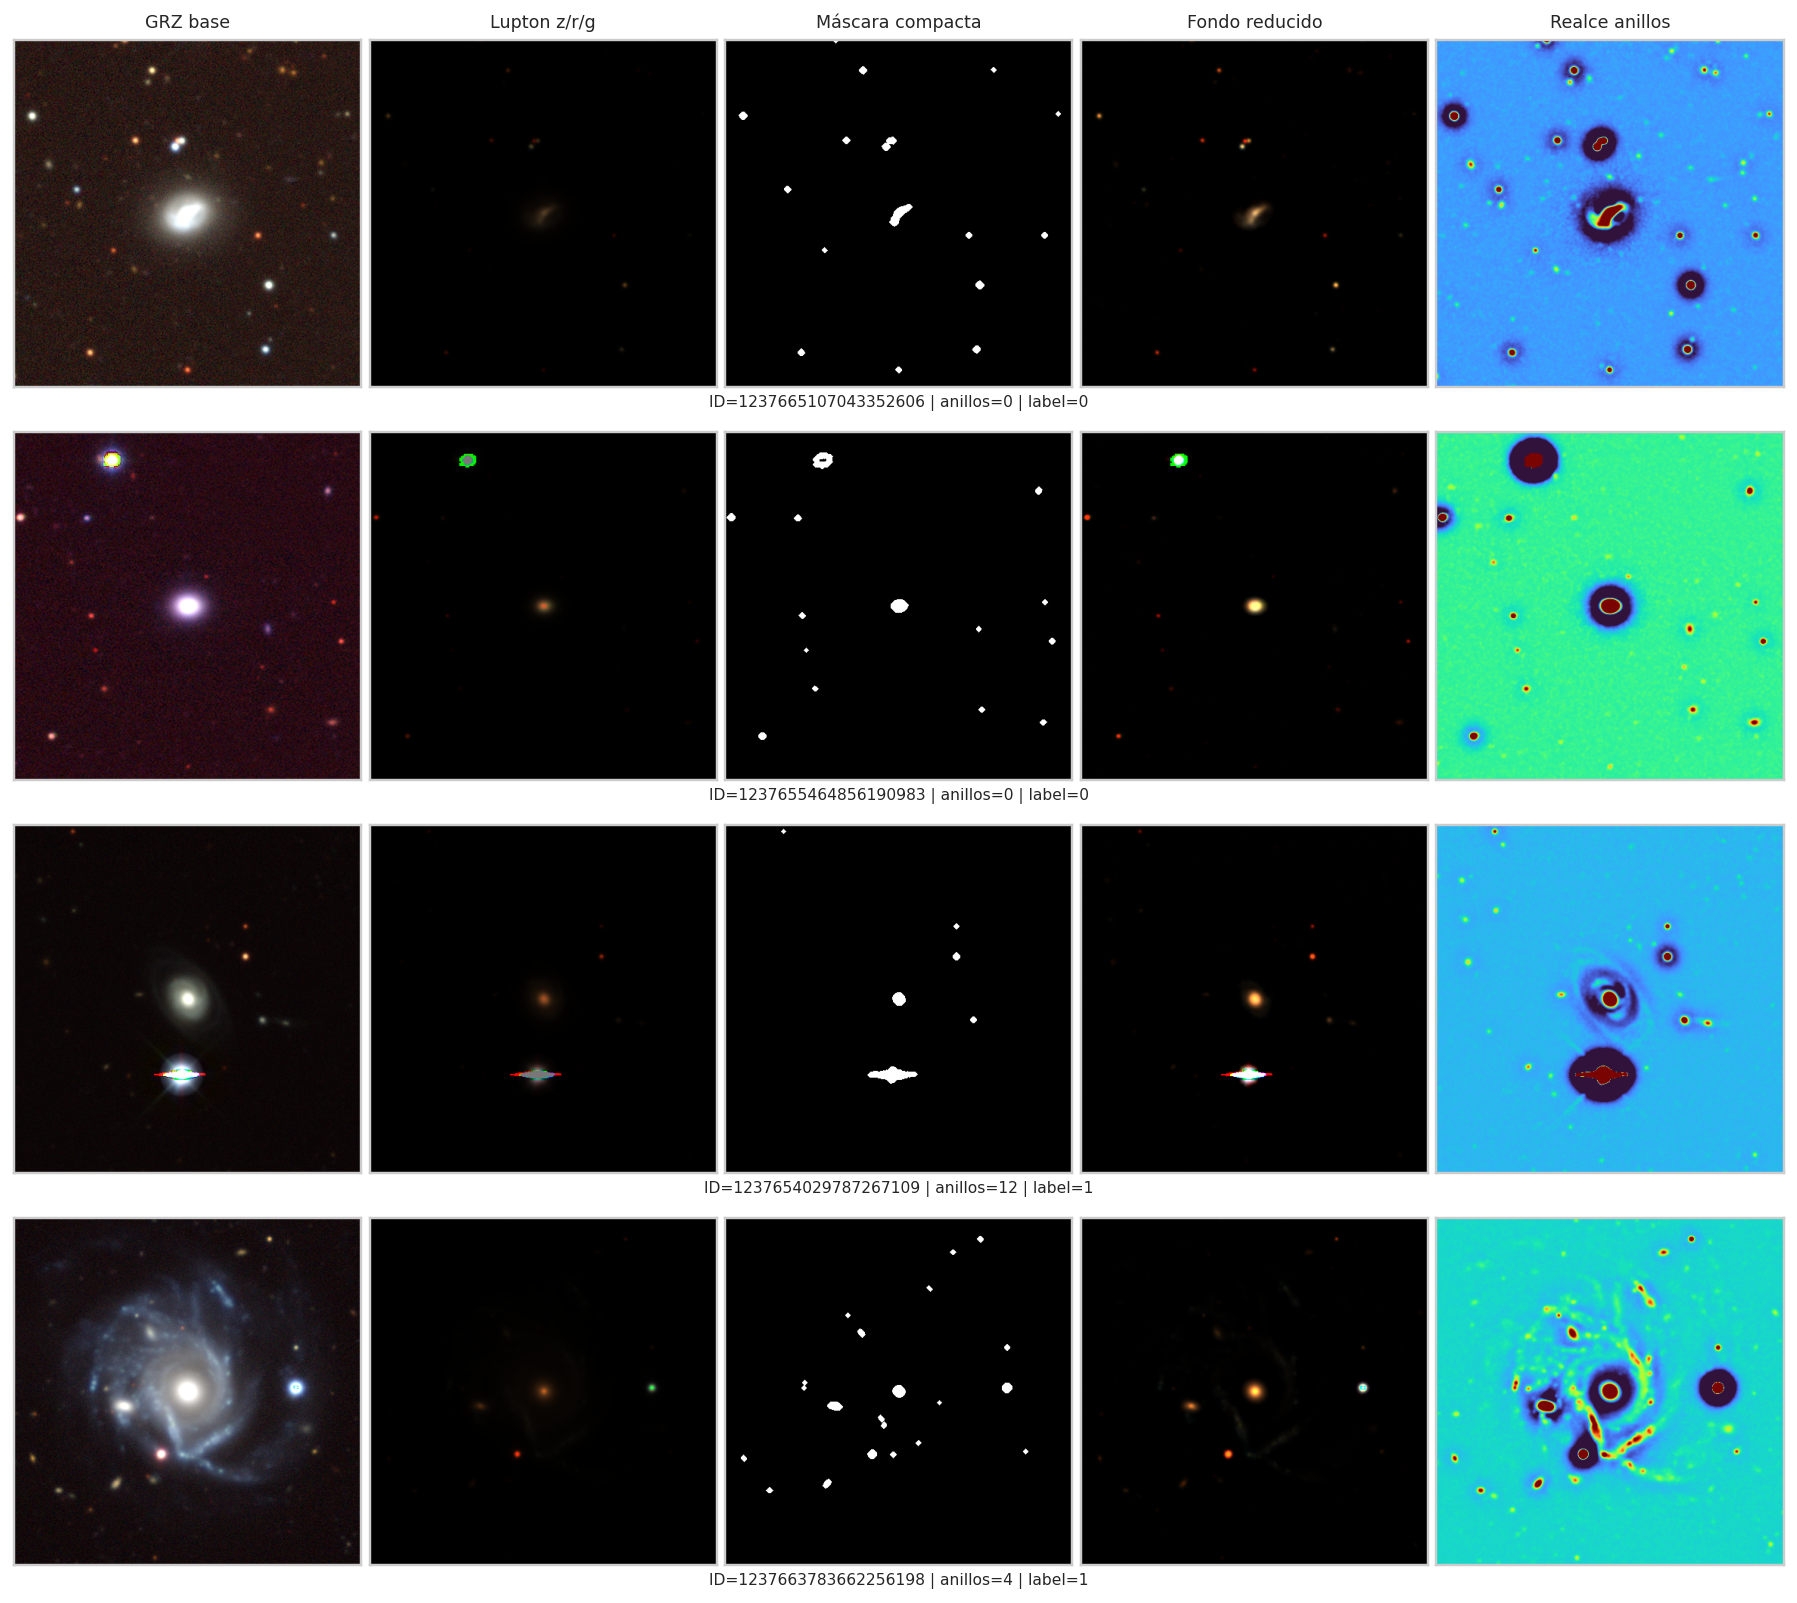

In [24]:
from scipy.ndimage import gaussian_filter, binary_opening, binary_dilation


def plot_lupton_processing_examples(input_df: pd.DataFrame, crop_size: int = 460) -> None:
    usable = input_df[input_df["has_image_features"].eq(1)].copy()
    preferred_ids = [
        "1237665107043352606",
        "1237655464856190983",
        "1237654029787267109",
        "1237663783662256198",
    ]

    rows = []
    for object_id in preferred_ids:
        match = usable[usable["name"].astype(str).eq(object_id)]
        if len(match):
            rows.append(match.iloc[0])

    if len(rows) < 4:
        fallback = pd.concat([
            usable[usable["label"].eq(0)].sample(n=2, random_state=7),
            usable[usable["label"].eq(1)].sort_values("lupton_lum_ring_contrast", ascending=False).head(2),
        ])
        rows = [row for _, row in fallback.iterrows()]

    examples = pd.DataFrame(rows).head(4)

    def center_crop_cube(cube: np.ndarray, size: int) -> np.ndarray:
        _, height, width = cube.shape
        y0 = max((height - size) // 2, 0)
        x0 = max((width - size) // 2, 0)
        return cube[:, y0:y0 + size, x0:x0 + size]

    def band_asinh(band: np.ndarray) -> np.ndarray:
        lo, hi = np.nanpercentile(band, [0.5, 99.7])
        if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
            return np.zeros_like(band, dtype="float32")
        scaled = np.clip(band, lo, hi)
        scaled = (scaled - lo) / (hi - lo + 1e-8)
        return (np.arcsinh(12 * scaled) / np.arcsinh(12)).astype("float32")

    def grz_base(cube: np.ndarray) -> np.ndarray:
        return np.dstack([band_asinh(cube[2]), band_asinh(cube[1]), band_asinh(cube[0])])

    def lupton_rgb(cube: np.ndarray) -> np.ndarray:
        rgb = make_lupton_rgb(cube[2], cube[1], cube[0], Q=8, stretch=5, output_dtype=float)
        rgb = np.nan_to_num(rgb, nan=0.0, posinf=0.0, neginf=0.0)
        return np.clip(rgb, 0, 1)

    def luminance(rgb: np.ndarray) -> np.ndarray:
        return (0.2126 * rgb[:, :, 0] + 0.7152 * rgb[:, :, 1] + 0.0722 * rgb[:, :, 2]).astype("float32")

    def compact_mask(lum: np.ndarray) -> np.ndarray:
        highpass = lum - gaussian_filter(lum, sigma=4)
        threshold = max(np.nanpercentile(highpass, 99.65), np.nanpercentile(lum, 99.4) * 0.15)
        mask = (highpass > threshold) & (lum > np.nanpercentile(lum, 92))
        mask = binary_opening(mask, iterations=1)
        mask = binary_dilation(mask, iterations=2)
        return mask.astype("float32")

    def background_reduced(rgb: np.ndarray) -> np.ndarray:
        bg = gaussian_filter(rgb, sigma=(18, 18, 0))
        reduced = (rgb - bg) * 3.0 + rgb * 0.55
        return np.clip(reduced, 0, 1)

    def ring_enhancement(rgb: np.ndarray) -> np.ndarray:
        lum = luminance(rgb)
        dog = gaussian_filter(lum, sigma=1.2) - gaussian_filter(lum, sigma=10)
        height, width = dog.shape
        yy, xx = np.indices((height, width))
        rr = np.sqrt((xx - (width - 1) / 2) ** 2 + (yy - (height - 1) / 2) ** 2)
        rr = rr / (rr.max() + 1e-8)
        dog = dog * (0.35 + 0.65 * np.clip(rr / 0.15, 0, 1))
        lo, hi = np.nanpercentile(dog, [2, 99.5])
        dog = np.clip((dog - lo) / (hi - lo + 1e-8), 0, 1)
        return plt.cm.turbo(dog)[:, :, :3]

    columns = ["GRZ base", "Lupton z/r/g", "Máscara compacta", "Fondo reducido", "Realce anillos"]
    fig, axes = plt.subplots(len(examples), len(columns), figsize=(13, 2.9 * len(examples)), dpi=140)
    if len(examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (_, row) in enumerate(examples.iterrows()):
        with fits.open(Path(row["fits_path"]), memmap=True) as hdul:
            cube = hdul[0].data.astype("float32", copy=False)
        crop = center_crop_cube(cube, crop_size)
        lupton = lupton_rgb(crop)
        panels = [
            grz_base(crop),
            lupton,
            compact_mask(luminance(lupton)),
            background_reduced(lupton),
            ring_enhancement(lupton),
        ]

        for col_idx, panel in enumerate(panels):
            ax = axes[row_idx, col_idx]
            if panel.ndim == 2:
                ax.imshow(panel, cmap="gray", vmin=0, vmax=1, origin="lower")
            else:
                ax.imshow(panel, origin="lower")
            if row_idx == 0:
                ax.set_title(columns[col_idx], fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])

        axes[row_idx, 2].set_xlabel(
            f"ID={row['name']} | anillos={int(row['anillos'])} | label={int(row['label'])}",
            fontsize=8,
        )

    plt.tight_layout(h_pad=1.0, w_pad=0.35)
    plt.show()


plot_lupton_processing_examples(fe)


## Split, binning y escalamiento

 Los bins y escaladores se ajustan solo con train; test no participa en esas decisiones. El split se estratifica por `source`, `label` y `has_fits`, porque si se rompe esa proporción luego el modelo puede parecer mejor, o peor, por una partición medio tramposa.


In [25]:
fe["source_label_fits_stratum"] = (
    fe["source"].astype(str) + "_" + fe["label"].astype(str) + "_" + fe["has_image_features"].astype(str)
)

train_idx, test_idx = train_test_split(
    fe.index,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=fe["source_label_fits_stratum"],
)

fe["split"] = "train"
fe.loc[test_idx, "split"] = "test"
train = fe.loc[train_idx].copy()
test = fe.loc[test_idx].copy()
train_img = train[train["has_image_features"] == 1].copy()

print(f"Train: {len(train)} | Test: {len(test)} | Train con features de imagen: {len(train_img)}")
display(pd.crosstab([fe["split"], fe["source"]], [fe["label"], fe["has_image_features"]]))


Train: 6726 | Test: 1682 | Train con features de imagen: 6480


label                 0         1     
has_image_features    0     1   0    1
split source                          
test  manga           0     0   0  104
      sdss           50  1282  11  235
train manga           0     0   2  413
      sdss          200  5128  44  939

In [26]:
tabular_continuous = [
    "ra_sin",
    "ra_cos",
    "dec_sin",
    "dec_cos",
    "gal_l_sin",
    "gal_l_cos",
    "gal_b_sin",
    "z_sqrt",
]

try:
    z_binner = KBinsDiscretizer(
        n_bins=4,
        encode="onehot-dense",
        strategy="quantile",
        quantile_method="linear",
    )
except TypeError:
    z_binner = KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")

z_binner.fit(train[["z_sqrt"]])
z_bin_cols = [f"z_bin_q{i+1}" for i in range(4)]
fe[z_bin_cols] = z_binner.transform(fe[["z_sqrt"]])

z_edges = pd.DataFrame({
    "edge_z_sqrt": z_binner.bin_edges_[0],
    "edge_nsa_z_equiv": z_binner.bin_edges_[0] ** 2,
})
display(z_edges)


,edge_z_sqrt,edge_nsa_z_equiv
0,0.084390,0.007122
1,0.157592,0.024835
2,0.181811,0.033055
3,0.212212,0.045034
4,0.384677,0.147977


In [27]:
tabular_scaler = StandardScaler().fit(train[tabular_continuous])
tabular_scaled_cols = [f"{col}_std" for col in tabular_continuous]
fe[tabular_scaled_cols] = tabular_scaler.transform(fe[tabular_continuous])

image_scaler = StandardScaler().fit(train_img[image_feature_cols])
image_scaled_cols = [f"{col}_std" for col in image_feature_cols]
fe[image_scaled_cols] = np.nan
fe.loc[fe["has_image_features"] == 1, image_scaled_cols] = image_scaler.transform(fe.loc[fe["has_image_features"] == 1, image_feature_cols])

source_ohe = pd.get_dummies(fe["source"], prefix="source", dtype=int)
fe = pd.concat([fe, source_ohe], axis=1)

print("Features tabulares escaladas:", len(tabular_scaled_cols))
print("Features de imagen escaladas:", len(image_scaled_cols))


Features tabulares escaladas: 8
Features de imagen escaladas: 27


## Selección por filtros

Revisamos la varianza, correlación, ANOVA y chi-cuadrado para quitar variables que aportan poco o que repiten casi lo mismo. Esta parte se calcula sobre filas con imagen disponible, porque ahí viven juntas las features tabulares y visuales.


In [28]:
model_scaled_candidates = tabular_scaled_cols + image_scaled_cols
X_train_img = fe.loc[train_img.index, model_scaled_candidates]
y_train_img = fe.loc[train_img.index, "label"]

variance_selector = VarianceThreshold(threshold=0.01).fit(X_train_img)
variance_report = pd.DataFrame({
    "feature": model_scaled_candidates,
    "variance": variance_selector.variances_,
    "kept": variance_selector.get_support(),
}).sort_values("variance")
display(variance_report)


,feature,variance,kept
1,ra_cos_std,0.982278,True
6,gal_b_sin_std,0.986686,True
4,gal_l_sin_std,0.989967,True
8,img_g_log_p99_pos_std,1.000000,True
12,img_z_log_p99_pos_std,1.000000,True
13,img_z_log_flux_pos_std,1.000000,True
9,img_g_log_flux_pos_std,1.000000,True
17,img_r_concentration_20_std,1.000000,True
21,img_r_asymmetry_180_std,1.000000,True
26,lupton_saturation_p95_std,1.000000,True


In [29]:
corr = X_train_img.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
correlation_threshold = 0.90
corr_drop = [col for col in upper.columns if any(upper[col] > correlation_threshold)]

corr_pairs = []
for col in upper.columns:
    for row in upper.index[upper[col] > correlation_threshold].tolist():
        corr_pairs.append({"feature_a": row, "feature_b": col, "abs_corr": float(upper.loc[row, col])})
corr_pairs = pd.DataFrame(corr_pairs).sort_values("abs_corr", ascending=False)

print("Variables retiradas por correlación > 0.90:")
print(corr_drop)
display(corr_pairs)


Variables retiradas por correlación > 0.90:
['dec_cos_std', 'gal_b_sin_std', 'img_r_log_flux_pos_std', 'lupton_lum_p99_std', 'lupton_lum_std_std', 'lupton_lum_asymmetry_180_std']


,feature_a,feature_b,abs_corr
3,img_r_log_p99_pos_std,lupton_lum_p99_std,0.969868
1,ra_cos_std,gal_b_sin_std,0.964256
2,img_g_log_flux_pos_std,img_r_log_flux_pos_std,0.957135
4,img_r_log_flux_pos_std,lupton_lum_std_std,0.927928
0,dec_sin_std,dec_cos_std,0.920051
5,lupton_lum_concentration_20_std,lupton_lum_asymmetry_180_std,0.911070


In [30]:
f_values, p_values = f_classif(X_train_img, y_train_img)
anova_report = pd.DataFrame({
    "feature": model_scaled_candidates,
    "f_value": f_values,
    "p_value": p_values,
}).sort_values("f_value", ascending=False)
display(anova_report.head(20))


,feature,f_value,p_value
25,lupton_saturation_mean_std,248.989057,0.000000
6,gal_b_sin_std,37.857748,0.000000
7,z_sqrt_std,36.368339,0.000000
1,ra_cos_std,33.062569,0.000000
5,gal_l_cos_std,24.224133,0.000001
0,ra_sin_std,21.473278,0.000004
14,img_gr_log_flux_ratio_std,15.365023,0.000090
29,lupton_lum_center_mean_std,14.295913,0.000158
34,lupton_lum_asymmetry_180_std,11.602390,0.000663
13,img_z_log_flux_pos_std,10.841162,0.000998


In [13]:
minmax_scaler = MinMaxScaler().fit(train_img[tabular_continuous + image_feature_cols])
minmax_cols = [f"{col}_minmax" for col in tabular_continuous + image_feature_cols]
fe[minmax_cols] = np.nan
fe.loc[fe["has_image_features"] == 1, minmax_cols] = minmax_scaler.transform(fe.loc[fe["has_image_features"] == 1, tabular_continuous + image_feature_cols])

chi_features = minmax_cols + z_bin_cols + list(source_ohe.columns)
X_chi = fe.loc[train_img.index, chi_features]
chi_scores, chi_p_values = chi2(X_chi, y_train_img)
chi_report = pd.DataFrame({
    "feature": chi_features,
    "chi2": chi_scores,
    "p_value": chi_p_values,
    "view": ["audit_source" if c.startswith("source_") else "model_candidate" for c in chi_features],
}).sort_values("chi2", ascending=False)
display(chi_report.head(25))


,feature,chi2,p_value,view
39,source_manga,1566.467456,0.000000,audit_source
40,source_sdss,106.634425,0.000000,audit_source
35,z_bin_q1,26.599583,0.000000,model_candidate
1,ra_cos_minmax,12.133915,0.000495,model_candidate
5,gal_l_cos_minmax,7.635049,0.005724,model_candidate
38,z_bin_q4,7.606744,0.005815,model_candidate
25,lupton_saturation_mean_minmax,7.425922,0.006429,model_candidate
36,z_bin_q2,6.596701,0.010217,model_candidate
0,ra_sin_minmax,3.973242,0.046229,model_candidate
6,gal_b_sin_minmax,2.715974,0.099348,model_candidate


**Decisión:** `source` se queda para auditoría. Aparece demasiado fuerte por cómo está construido el dataset, y eso sería una ventaja si se usa para entrenar. Las variables de imagen, textura y morfología sí se conservan, porque al menos intentan describir el objeto observado y no solo su origen en el catálogo.


## Extracción de características: PCA y FA

PCA entra como una forma de comprimir las características seleccionadas sin perder demasiada varianza. FA lo dejamos más como diagnóstico que como gran explicación física. Si KMO sale bajo, no conviene vender esos factores como si fueran una estructura latente sólida. Sería forzar la lectura.


In [31]:
selected_scaled_cols = [col for col in model_scaled_candidates if col not in corr_drop]
X_pca_train = fe.loc[train_img.index, selected_scaled_cols]
X_pca_all_img = fe.loc[fe["has_image_features"] == 1, selected_scaled_cols]

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca.fit(X_pca_train)
pca_cols = [f"pca_{i+1}" for i in range(pca.n_components_)]

fe[pca_cols] = np.nan
fe.loc[fe["has_image_features"] == 1, pca_cols] = pca.transform(X_pca_all_img)

pca_report = pd.DataFrame({
    "component": pca_cols,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})
display(pca_report)


,component,explained_variance_ratio,cumulative_explained_variance
0,pca_1,0.253765,0.253765
1,pca_2,0.156720,0.410485
2,pca_3,0.085388,0.495873
3,pca_4,0.072946,0.568819
4,pca_5,0.061242,0.630061
5,pca_6,0.046587,0.676647
6,pca_7,0.042825,0.719472
7,pca_8,0.035401,0.754874
8,pca_9,0.033459,0.788333
9,pca_10,0.031631,0.819964


In [15]:
fa_summary = {"kmo": None, "bartlett_p_value": None}
if FACTOR_ANALYZER_AVAILABLE:
    kmo_all, kmo_model = calculate_kmo(X_pca_train)
    bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(X_pca_train)
    fa_summary = {"kmo": float(kmo_model), "bartlett_p_value": float(bartlett_p)}

factor_analysis = FactorAnalysis(n_components=2, random_state=RANDOM_STATE)
factor_analysis.fit(X_pca_train)
fa_cols = ["fa_1", "fa_2"]
fe[fa_cols] = np.nan
fe.loc[fe["has_image_features"] == 1, fa_cols] = factor_analysis.transform(X_pca_all_img)

fa_loadings = pd.DataFrame(factor_analysis.components_.T, index=selected_scaled_cols, columns=fa_cols)
print(json.dumps(fa_summary, indent=2, ensure_ascii=False))
display(fa_loadings.reindex(fa_loadings.abs().max(axis=1).sort_values(ascending=False).index).head(20))


{
  "kmo": 0.7153705139147041,
  "bartlett_p_value": 0.0
}


/tmp/ipykernel_57201/464872793.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fe[fa_cols] = np.nan


,fa_1,fa_2
lupton_lum_mean_std,0.928449,0.085935
img_r_concentration_20_std,0.153012,0.887804
lupton_lum_center_mean_std,0.271906,0.852734
img_r_asymmetry_180_std,0.848446,-0.206455
img_z_log_flux_pos_std,0.839260,0.152867
img_g_log_flux_pos_std,0.820134,0.030101
img_r_log_p99_pos_std,0.807794,-0.024488
lupton_lum_concentration_20_std,-0.383007,0.741892
img_z_log_p99_pos_std,0.731979,0.111391
img_r_center_mean_std,-0.675446,0.513456



Creamos el **empaquetado final de la preparación de datos**. Sirve para dejar todo ordenado antes de pasar al modelado:

- reunimos en una sola tabla las variables originales necesarias para trazabilidad, las features tabulares, las features de imagen/Lupton, los bins, las variables escaladas y las componentes PCA/FA;
- dejamos fijo el split `train/test`, así el notebook de modelado no inventa otra partición sin querer;
- documentamos principalmente qué columnas son referencia o auditoría (`name`, `anillos`, `source`, `has_fits`, `has_image_features`) y cuáles sí pueden entrar como candidatas de entrenamiento;
- bajamos el desorden: en vez de muchos CSV intermedios, queda un dataset integrado y un JSON de resumen.


In [16]:
reference_cols = [
    "name",
    "source",
    "anillos",
    "label",
    "split",
    "has_fits",
    "has_image_features",
    "fits_path",
    "objra",
    "objdec",
    "nsa_z",
]

tabular_engineered_cols = [
    "ra_sin",
    "ra_cos",
    "dec_sin",
    "dec_cos",
    "gal_l",
    "gal_b",
    "gal_l_sin",
    "gal_l_cos",
    "gal_b_sin",
    "gal_b_abs",
    "z_log1p",
    "z_sqrt",
]

final_cols = (
    reference_cols
    + tabular_engineered_cols
    + image_feature_cols
    + z_bin_cols
    + tabular_scaled_cols
    + image_scaled_cols
    + pca_cols
    + fa_cols
)

final_dataset = fe[final_cols].copy()
final_dataset["fits_path"] = final_dataset["fits_path"].astype("string")

final_csv_path = OUTPUT_DIR / "feature_engineered_dataset.csv"
final_dataset.to_csv(final_csv_path, index=False)

model_recommended_cols = [col for col in selected_scaled_cols if not col.startswith("source_")] + z_bin_cols
image_model_filter = "has_image_features == 1"

summary = {
    "output_csv": str(final_csv_path.relative_to(PROJECT_ROOT)),
    "rows": int(final_dataset.shape[0]),
    "columns": int(final_dataset.shape[1]),
    "rows_with_image_features": int(final_dataset["has_image_features"].sum()),
    "rows_without_image_features": int((final_dataset["has_image_features"] == 0).sum()),
    "failed_fits": int(len(failed_fits)),
    "tabular_features": tabular_engineered_cols,
    "image_features": image_feature_cols,
    "lupton_downsample_factor": LUPTON_DOWNSAMPLE,
    "z_binning_edges_raw_nsa_z": (z_binner.bin_edges_[0] ** 2).tolist(),
    "dropped_by_correlation_threshold_0_90": corr_drop,
    "recommended_model_columns": model_recommended_cols,
    "recommended_filter_for_image_model": image_model_filter,
    "pca_components_for_95pct_variance": int(pca.n_components_),
    "pca_cumulative_variance": float(np.cumsum(pca.explained_variance_ratio_)[-1]),
    "factor_analysis": fa_summary,
    "excluded_as_predictors": {
        "name": "identificador único",
        "anillos": "codificación original usada para derivar label; sería leakage",
        "source": "sesgado por construcción; MaNGA solo aporta positivos, usar solo para auditoría/estratificación",
        "has_fits": "estado operativo de descarga; no usar como señal física",
        "has_image_features": "control de calidad de extracción; usar para filtrar modelos de imagen, no como señal física",
    },
}

summary_path = OUTPUT_DIR / "feature_engineering_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Archivo guardado:", final_csv_path.relative_to(PROJECT_ROOT), final_dataset.shape)
print("Resumen guardado:", summary_path.relative_to(PROJECT_ROOT))


Archivo guardado: feature_engineering/output/feature_engineered_dataset.csv (8408, 108)
Resumen guardado: feature_engineering/output/feature_engineering_summary.json


## Conclusiones

- La preparación queda alineada con CRISP-ML: se revisó calidad, se dejó visible el sesgo, se crearon features, se escalaron variables y se redujo dimensionalidad antes del modelado.
- De las imágenes FITS se extrajeron descriptores morfológicos y fotométricos compactos, sin guardar pixeles crudos.
- `source` confirma un sesgo de catálogo. Pensamos que es mejor tenerlo a la vista que dejar que se cuele como predictor principal.
- `has_fits` ayuda a separar dos escenarios: un modelo tabular con todas las filas y otro tabular+imagen filtrando `has_image_features=1`.
- `sqrt(z)`, los bins por cuantiles y el escalamiento estándar reducen problemas de escala y deberían ayudar a modelos lineales, SVM o redes a entrenar con menos fricción.
- PCA deja una versión compacta de las features. FA queda en modo diagnóstico; si KMO no acompaña, no hay que sobreinterpretarlo.

**Referencias:**

- Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). CRISP-ML(Q). https://ml-ops.org/content/crisp-ml

- [Lupton, R. et al. (2004). *Preparing Red-Green-Blue Images from CCD Data*. PASP.](https://arxiv.org/abs/astro-ph/0312483)
- [Astropy Visualization. `make_lupton_rgb`.](https://docs.astropy.org/en/latest/api/astropy.visualization.make_lupton_rgb.html)
- [Conselice, C. (2003). *The Relationship Between Stellar Light Distributions of Galaxies and their Formation Histories*.](https://arxiv.org/abs/astro-ph/0303065)
- [Lotz, J. et al. (2004). *A New Non-Parametric Approach to Galaxy Morphological Classification*.](https://arxiv.org/abs/astro-ph/0311352)
